In [1]:
# Cell 1 — Build the exact training dataset
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from ml_pipeline.training.dataset import build_training_dataset

X, y, groups = build_training_dataset()
print(f"Shape: {X.shape}")
print(f"Features: {list(X.columns)}")
print(f"\nClass balance: {y.value_counts().to_dict()}")
print(f"Fraud rate: {y.mean()*100:.1f}%")

  Dataset: 43,576 rows | Fraud: 6,789 (15.6%) | Features: 12
Shape: (43576, 12)
Features: ['velocity_1h', 'velocity_6h', 'velocity_24h', 'amount_ratio', 'device_trust_score', 'ip_fraud_history', 'merchant_risk_score', 'hour_of_day', 'day_of_week', 'is_new_device', 'is_late_night', 'is_new_user']

Class balance: {0: 36787, 1: 6789}
Fraud rate: 15.6%


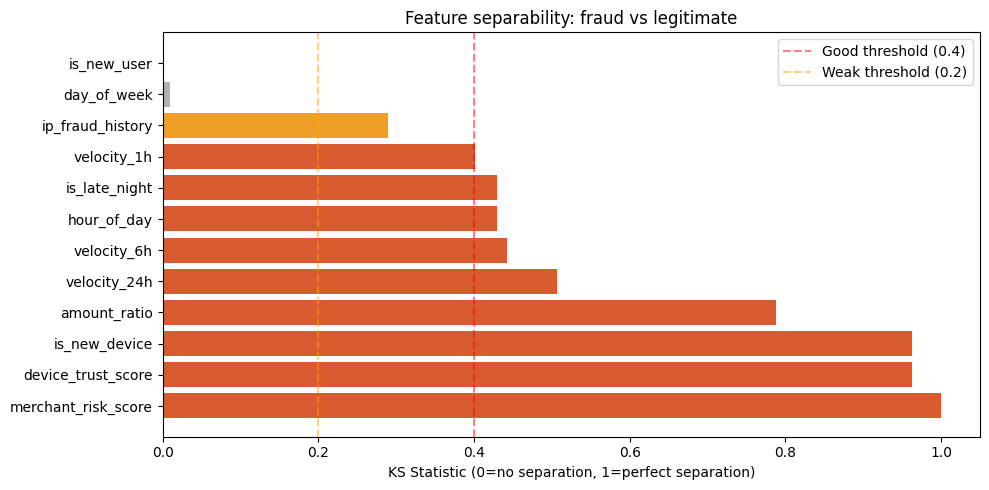


KS scores:
            feature  ks_stat
merchant_risk_score 1.000000
 device_trust_score 0.962786
      is_new_device 0.962786
       amount_ratio 0.787781
       velocity_24h 0.506593
        velocity_6h 0.442993
        hour_of_day 0.429104
      is_late_night 0.429104
        velocity_1h 0.400981
   ip_fraud_history 0.289586
        day_of_week 0.009681
        is_new_user 0.000000


In [2]:
# Cell 2 — KS statistic: how well does each feature separate classes?
from scipy.stats import ks_2samp

fraud_X = X[y == 1]
legit_X = X[y == 0]

results = []
for col in X.columns:
    ks, p = ks_2samp(fraud_X[col].dropna(), legit_X[col].dropna())
    results.append({"feature": col, "ks_stat": ks, "p_value": p})

ks_df = pd.DataFrame(results).sort_values("ks_stat", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#D85A30" if ks > 0.4 else "#EF9F27" if ks > 0.2 else "#B4B2A9"
          for ks in ks_df["ks_stat"]]
bars = ax.barh(ks_df["feature"], ks_df["ks_stat"], color=colors)
ax.axvline(0.4, color="red", linestyle="--", alpha=0.5, label="Good threshold (0.4)")
ax.axvline(0.2, color="orange", linestyle="--", alpha=0.5, label="Weak threshold (0.2)")
ax.set_xlabel("KS Statistic (0=no separation, 1=perfect separation)")
ax.set_title("Feature separability: fraud vs legitimate")
ax.legend()
plt.tight_layout()
plt.show()

print("\nKS scores:")
print(ks_df[["feature","ks_stat"]].to_string(index=False))

In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


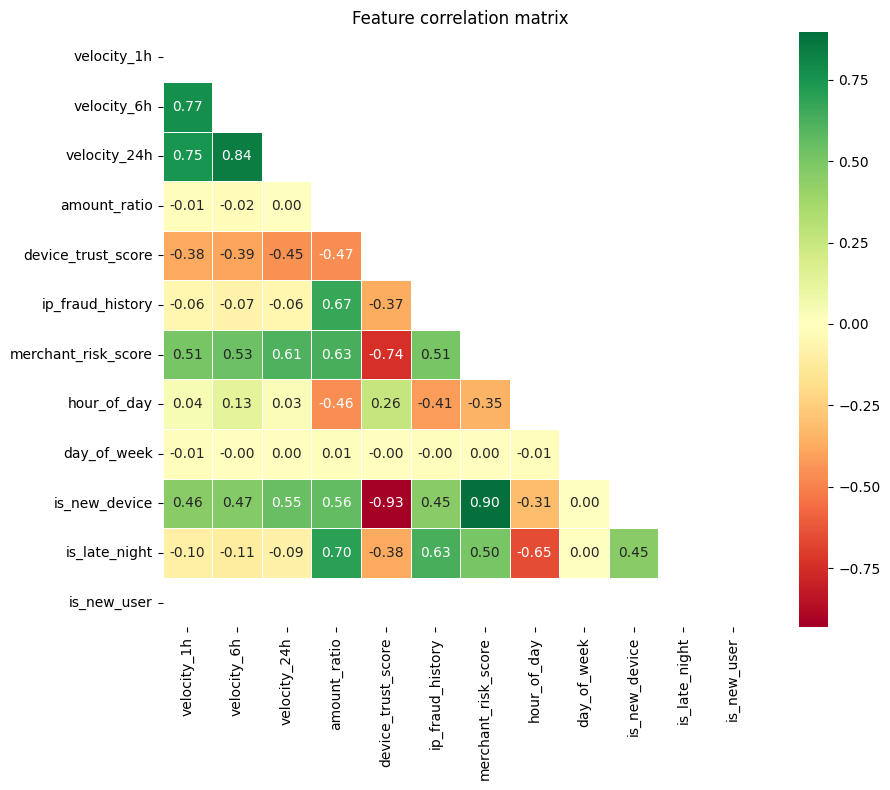


High correlations (|r| > 0.5):
  velocity_1h ↔ velocity_6h: 0.771
  velocity_1h ↔ velocity_24h: 0.747
  velocity_1h ↔ merchant_risk_score: 0.509
  velocity_6h ↔ velocity_24h: 0.839
  velocity_6h ↔ merchant_risk_score: 0.532
  velocity_24h ↔ merchant_risk_score: 0.613
  velocity_24h ↔ is_new_device: 0.546
  amount_ratio ↔ ip_fraud_history: 0.669
  amount_ratio ↔ merchant_risk_score: 0.627
  amount_ratio ↔ is_new_device: 0.564
  amount_ratio ↔ is_late_night: 0.697
  device_trust_score ↔ merchant_risk_score: -0.740
  device_trust_score ↔ is_new_device: -0.931
  ip_fraud_history ↔ merchant_risk_score: 0.506
  ip_fraud_history ↔ is_late_night: 0.629
  merchant_risk_score ↔ is_new_device: 0.895
  merchant_risk_score ↔ is_late_night: 0.504
  hour_of_day ↔ is_late_night: -0.654


In [5]:
# Cell 3 — Feature correlation matrix
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 8))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

# High correlations to watch
print("\nHigh correlations (|r| > 0.5):")
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        r = corr.iloc[i, j]
        if abs(r) > 0.5:
            print(f"  {corr.index[i]} ↔ {corr.columns[j]}: {r:.3f}")

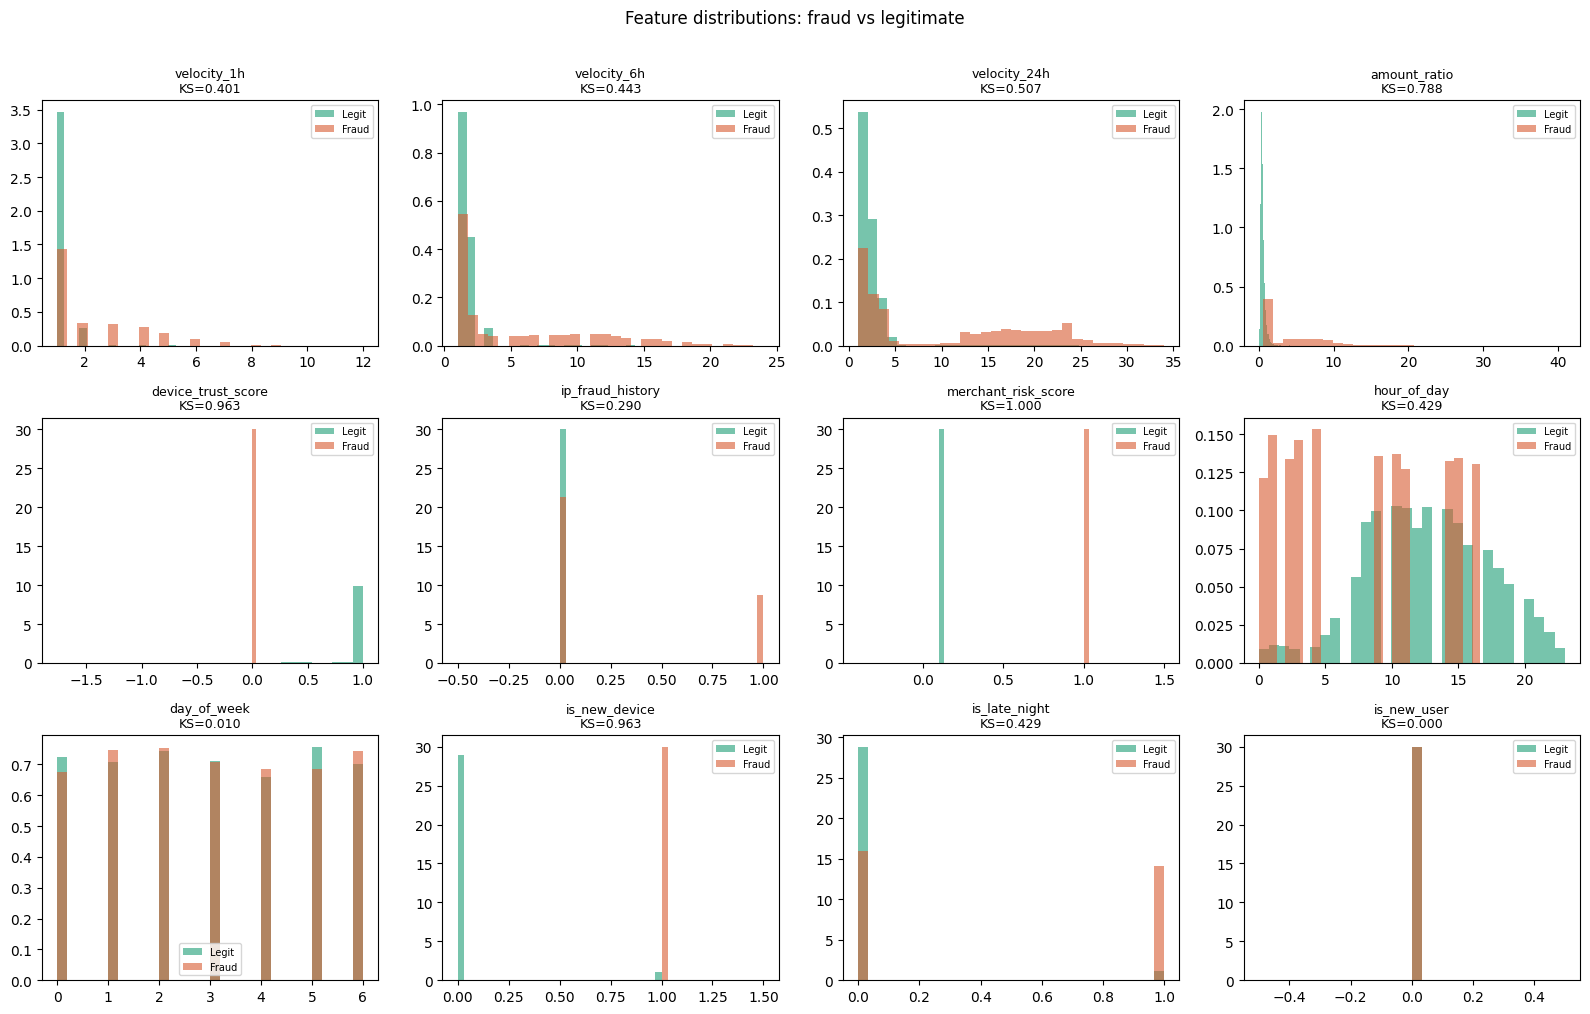

In [6]:
# Cell 4 — Feature distributions side by side
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(X.columns):
    ax = axes[idx]
    ax.hist(legit_X[col], bins=30, color="#1D9E75", alpha=0.6,
            label="Legit", density=True)
    ax.hist(fraud_X[col], bins=30, color="#D85A30", alpha=0.6,
            label="Fraud", density=True)
    ks = ks_df[ks_df.feature == col]["ks_stat"].values[0]
    ax.set_title(f"{col}\nKS={ks:.3f}", fontsize=9)
    ax.legend(fontsize=7)

for idx in range(len(X.columns), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Feature distributions: fraud vs legitimate", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [7]:
# Cell 5 — Temporal leakage check
# Confirm we're using point-in-time correct features
print("=== Temporal Leakage Check ===\n")
print("velocity_1h in training = COUNT(*) WHERE created_at > txn.created_at - 1h")
print("This uses ONLY past data at the moment of the transaction.")
print("It does NOT use current Redis velocity (which would be future data).\n")

# Check: do velocity features look reasonable?
print("Velocity feature statistics:")
for col in ["velocity_1h", "velocity_6h", "velocity_24h"]:
    print(f"  {col}:  mean={X[col].mean():.2f}  max={X[col].max():.0f}  "
          f"fraud_mean={fraud_X[col].mean():.2f}  legit_mean={legit_X[col].mean():.2f}")

print("\nIf fraud_mean >> legit_mean for velocity → signal is real, not leakage")

=== Temporal Leakage Check ===

velocity_1h in training = COUNT(*) WHERE created_at > txn.created_at - 1h
This uses ONLY past data at the moment of the transaction.
It does NOT use current Redis velocity (which would be future data).

Velocity feature statistics:
  velocity_1h:  mean=1.28  max=12  fraud_mean=2.31  legit_mean=1.09
  velocity_6h:  mean=2.08  max=24  fraud_mean=5.46  legit_mean=1.45
  velocity_24h:  mean=3.84  max=34  fraud_mean=10.96  legit_mean=2.53

If fraud_mean >> legit_mean for velocity → signal is real, not leakage
